# Passo 3 - Treinamento do Modelo MLP

Este notebook tem como objetivo treinar um modelo de rede neural do tipo MLP (Multilayer Perceptron) para prever o nível de engajamento dos usuários no contexto do projeto WellMe.

Nesta etapa, serão utilizados os dados previamente tratados no notebook anterior, incluindo a variável alvo `Engagement`, criada a partir de indicadores de atividade física, tempo sedentário e gasto calórico.

Também será realizada a normalização dos dados, etapa importante para modelos de redes neurais, pois as variáveis possuem escalas diferentes.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv('../data/processed/fitbit_processed.csv')

df.head()

,Id,ActivityDate,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Engagement
0,1503960366,3/25/2016,11004,33,12,205,804,1819,Medium
1,1503960366,3/26/2016,17609,89,17,274,588,2154,High
2,1503960366,3/27/2016,12736,56,5,268,605,1944,High
3,1503960366,3/28/2016,13231,39,20,224,1080,1932,High
4,1503960366,3/29/2016,12041,28,28,243,763,1886,High


In [5]:
X = df[
    [
        'TotalSteps',
        'VeryActiveMinutes',
        'FairlyActiveMinutes',
        'LightlyActiveMinutes',
        'SedentaryMinutes',
        'Calories'
    ]
]

y = df['Engagement']

In [6]:
X.head()

,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,11004,33,12,205,804,1819
1,17609,89,17,274,588,2154
2,12736,56,5,268,605,1944
3,13231,39,20,224,1080,1932
4,12041,28,28,243,763,1886


In [7]:
y.head()

0    Medium
1      High
2      High
3      High
4      High
Name: Engagement, dtype: object

## Separação das Variáveis

Nesta etapa, foram separadas as variáveis de entrada (`features`) e a variável alvo (`target`) do modelo.

As variáveis de entrada representam comportamentos relacionados à atividade física, tempo sedentário e gasto calórico dos usuários.

A variável `Engagement` foi definida como variável alvo, pois representa o nível de engajamento que o modelo MLP deverá prever.

In [8]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

y_encoded[:10]

array([2, 0, 0, 0, 0, 2, 0, 0, 0, 0])

In [9]:
dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

{'High': 0, 'Low': 1, 'Medium': 2}

## Codificação da Variável Alvo

Como o modelo MLP trabalha com valores numéricos, a variável alvo `Engagement`, que possui categorias em texto, foi convertida para valores numéricos.

Esse processo foi realizado com `LabelEncoder`, transformando as classes `High (0)`, `Low (1)` e `Medium (2)` em números que podem ser interpretados pelo modelo.

Essa etapa é necessária para permitir o treinamento do modelo de classificação.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Normalização dos Dados

As variáveis utilizadas no modelo apresentam escalas diferentes, como número de passos, minutos ativos e calorias.

Para evitar que variáveis com valores maiores influenciem excessivamente o treinamento da rede neural, foi realizada a normalização dos dados utilizando `StandardScaler`.

Essa técnica transforma os dados para uma escala padronizada, com média próxima de zero e desvio padrão próximo de um, contribuindo para um melhor desempenho do modelo MLP.

Além disso, os dados foram divididos em conjuntos de treino e teste, permitindo avaliar a capacidade de generalização do modelo.

In [12]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

## Treinamento do Modelo MLP

Nesta etapa, foi criado e treinado um modelo MLP (Multilayer Perceptron), uma rede neural artificial utilizada para problemas de classificação.

O modelo foi configurado com duas camadas ocultas, contendo 64 e 32 neurônios, respectivamente. Essa estrutura permite que a rede neural aprenda padrões mais complexos presentes nos dados relacionados ao comportamento dos usuários.

A função de ativação utilizada foi `relu` (Rectified Linear Unit), escolhida por apresentar bom desempenho em redes neurais e facilitar o aprendizado do modelo, além de reduzir problemas relacionados ao desaparecimento de gradientes durante o treinamento.

O otimizador utilizado foi o `adam` (Adaptive Moment Estimation), amplamente utilizado em aplicações de Deep Learning devido à sua eficiência e capacidade de ajustar automaticamente a taxa de aprendizado durante o treinamento, contribuindo para uma convergência mais estável e rápida.

O objetivo do modelo é aprender padrões presentes nas variáveis de entrada para prever o nível de engajamento dos usuários no contexto do projeto WellMe.

In [13]:
y_pred = mlp_model.predict(X_test_scaled)

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.92


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        48
           1       0.96      0.96      0.96        23
           2       0.85      0.81      0.83        21

    accuracy                           0.92        92
   macro avg       0.92      0.91      0.91        92
weighted avg       0.92      0.92      0.92        92



In [16]:
import matplotlib.pyplot as plt

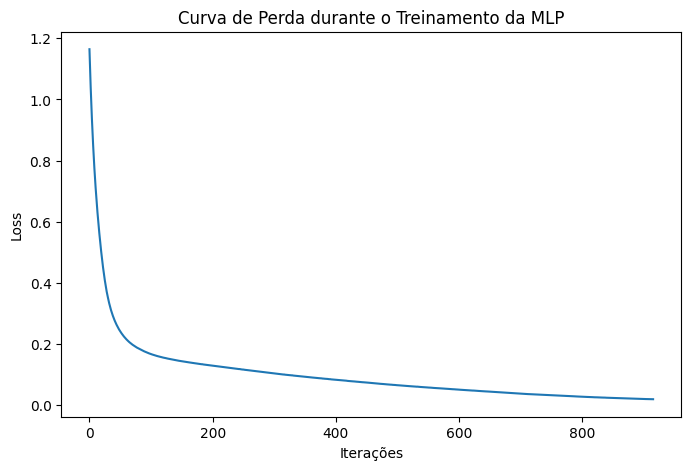

In [20]:
plt.figure(figsize=(8,5))

plt.plot(mlp_model.loss_curve_)

plt.title('Curva de Perda durante o Treinamento da MLP')
plt.xlabel('Iterações')
plt.ylabel('Loss')

plt.show()

## Curva de Perda durante o Treinamento

A curva de perda apresenta o comportamento do modelo ao longo das iterações de treinamento.

No `MLPClassifier`, o parâmetro `max_iter` representa o número máximo de iterações realizadas durante o treinamento. Embora o termo `epochs` seja mais comum em bibliotecas como TensorFlow e Keras, no Scikit-learn essa evolução pode ser acompanhada por meio da curva de perda (`loss_curve_`).

Essa análise permite observar se o modelo está aprendendo ao longo do treinamento. Quando a perda diminui de forma progressiva, isso indica que a rede neural está ajustando seus pesos e reduzindo os erros durante o processo de aprendizagem.

In [23]:
import seaborn as sns

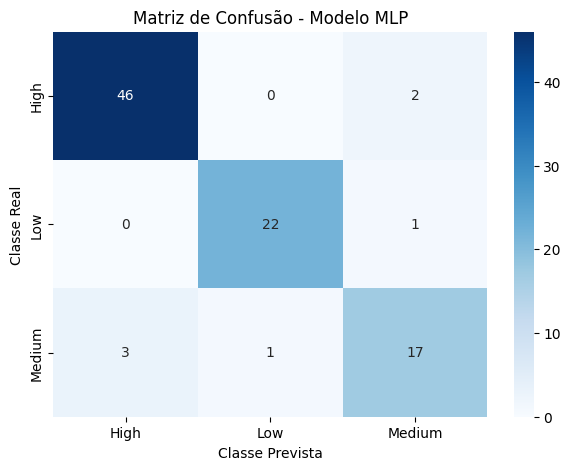

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Matriz de Confusão - Modelo MLP')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')

plt.show()

## Análise da Matriz de Confusão

A matriz de confusão apresenta o desempenho do modelo MLP na classificação dos níveis de engajamento dos usuários.

Observa-se que a maior parte das previsões corretas está concentrada na diagonal principal da matriz, indicando que o modelo conseguiu identificar adequadamente as classes de engajamento.

A classe `High` apresentou o melhor desempenho, com 46 classificações corretas e apenas 2 erros, demonstrando que o modelo conseguiu reconhecer com alta precisão os usuários com maior nível de engajamento.

A classe `Low` também apresentou bom resultado, com 22 previsões corretas e apenas 1 erro de classificação, indicando boa capacidade do modelo em identificar usuários com baixo engajamento.

Já a classe `Medium` apresentou maior dificuldade de distinção, com alguns registros sendo classificados como `High` e `Low`. Esse comportamento é esperado, pois usuários com engajamento intermediário tendem a apresentar características mais próximas das demais classes, tornando a separação mais complexa.

De forma geral, os resultados demonstram que o modelo apresentou bom desempenho na classificação dos diferentes níveis de engajamento, com poucos erros e boa capacidade de generalização.

No contexto do projeto WellMe, isso indica que a rede neural foi capaz de aprender padrões relevantes relacionados ao comportamento dos usuários, contribuindo para a proposta de previsão de engajamento dentro da aplicação.

# Conclusão do Treinamento do Modelo

A partir do treinamento do modelo MLP, foi possível desenvolver uma solução capaz de identificar padrões relacionados ao comportamento dos usuários e prever seus níveis de engajamento.

Os resultados obtidos demonstraram que variáveis como número de passos, tempo sedentário, minutos de atividade física e calorias gastas possuem relação direta com o nível de engajamento dos usuários no contexto do WellMe.

A utilização da rede neural MLP apresentou desempenho satisfatório, com boa capacidade de classificação das diferentes categorias de engajamento e baixo número de erros observados na matriz de confusão.

Além disso, a curva de perda do treinamento indicou evolução consistente do aprendizado ao longo das iterações, demonstrando que o modelo conseguiu ajustar seus parâmetros de forma adequada durante o treinamento.

De forma geral, o projeto demonstrou como técnicas de Machine Learning podem ser aplicadas no contexto de saúde e bem-estar para apoiar análises comportamentais e futuras estratégias de personalização dentro da aplicação WellMe.